In [ ]:
import yfinance as yf
import pandas as pd

print("Loading existing master dataset...")
master_df = pd.read_parquet("C:\Jai's work\PycharmProjects\Stock_predictor_new\dataset_ready.parquet")

start_date = master_df['Date'].min()
end_date = master_df['Date'].max()

print(f"Fetching VIX data from {start_date.date()} to {end_date.date()}...")
vix_data = yf.download('^VIX', start=start_date, end=end_date + pd.Timedelta(days=1))

vix_df = vix_data[['Close']].reset_index()
vix_df.columns = ['Date', 'VIX_Close'] 
vix_df['Date'] = pd.to_datetime(vix_df['Date']).dt.tz_localize(None)

print("Merging VIX into the master dataset...")
master_df_v2 = pd.merge(master_df, vix_df, on='Date', how='left')

master_df_v2['VIX_Close'] = master_df_v2['VIX_Close'].ffill().bfill()

output_file = 'dataset_ready.parquet'
master_df_v2.to_parquet(output_file, engine='pyarrow')
print(f"Successfully saved upgraded dataset to {output_file}")

<>:6: SyntaxWarning: "\J" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\J"? A raw string is also an option.
<>:6: SyntaxWarning: "\J" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\J"? A raw string is also an option.
C:\Users\Jai\AppData\Local\Temp\ipykernel_11612\1601134986.py:6: SyntaxWarning: "\J" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\J"? A raw string is also an option.
  master_df = pd.read_parquet("C:\Jai's work\PycharmProjects\Stock_predictor_new\dataset_ready.parquet")
[*********************100%***********************]  1 of 1 completed

Loading existing master dataset...
Fetching VIX data from 2021-07-02 to 2026-04-20...
Merging VIX into the master dataset...
Successfully saved upgraded dataset to dataset_ready.parquet


In [ ]:
import pandas as pd
import numpy as np
from pytorch_forecasting import TimeSeriesDataSet

df = pd.read_parquet("C:\Jai's work\PycharmProjects\Stock_predictor_new\codebase\dataset_ready.parquet")

df = df.sort_values(by=['Ticker', 'Date'])
df['time_idx'] = df.groupby('Ticker').cumcount()

df['DayOfWeek'] = df['Date'].dt.dayofweek.astype(str)

max_encoder_length = 21  # Look back 21 trading days (1 month)
max_prediction_length = 1  # Predict 1 day into the future


training_cutoff = df["time_idx"].max() - 30

training_dataset = TimeSeriesDataSet(
    df[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="Target_Next_Day_Return",
    group_ids=["Ticker"], 
    min_encoder_length=max_encoder_length,  
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    
    static_categoricals=["Ticker"],
    
    time_varying_known_categoricals=["DayOfWeek"],
    time_varying_known_reals=["time_idx"],
    
    time_varying_unknown_reals=[
        "Close", 
        "Volume", 
        "Daily_Return", 
        "Vol_14D", 
        "RSI_14", 
        "MACD", 
        "OBV", 
        "Dist_From_50SMA", 
        "Sentiment_Score",
        "VIX_Close"  
    ],
    
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

print(f"Number of training sequences generated: {len(training_dataset)}")

validation_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset, 
    df, 
    predict=True, 
    stop_randomization=True
)

Number of training sequences generated: 5765


<>:6: SyntaxWarning: "\J" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\J"? A raw string is also an option.
<>:6: SyntaxWarning: "\J" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\J"? A raw string is also an option.
C:\Users\Jai\AppData\Local\Temp\ipykernel_11612\3559854.py:6: SyntaxWarning: "\J" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\J"? A raw string is also an option.
  df = pd.read_parquet("C:\Jai's work\PycharmProjects\Stock_predictor_new\codebase\dataset_ready.parquet")


In [ ]:
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
import torch
import pytorch_optimizer


batch_size = 64  
train_dataloader = training_dataset.to_dataloader(train=True, batch_size=batch_size, num_workers=4, persistent_workers=True)
val_dataloader = validation_dataset.to_dataloader(train=False, batch_size=batch_size, num_workers=4, persistent_workers=True)


early_stop_callback = EarlyStopping(
    monitor="val_loss", 
    min_delta=1e-4, 
    patience=5, 
    verbose=True, 
    mode="min"
)
lr_logger = LearningRateMonitor(logging_interval="epoch")


trainer = pl.Trainer(
    max_epochs=120,
    accelerator="gpu",
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[lr_logger, early_stop_callback],
    enable_model_summary=True
)

print("Initiating the TFT model")
tft = TemporalFusionTransformer.from_dataset(
    training_dataset,
    
    
    learning_rate=0.01,
    hidden_size=64,          
    attention_head_size=8,   
    dropout=0.1,             
    hidden_continuous_size=8,
    
    
    loss=QuantileLoss(quantiles=[0.1, 0.5, 0.9]),
    
    optimizer="ranger" 
)

print(f"Number of parameters in network: {tft.size()/1e3:.1f}k")

print("Initiating Training Loop...")
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

model_path = "tft_finance_model_2.ckpt"
trainer.save_checkpoint(model_path)
print(f"Training complete! Model saved to {model_path}")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Initiating the TFT model
Number of parameters in network: 237.7k
Initiating Training Loop...


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     40 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    240 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  5.3 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 22.5 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  3.8 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │  9.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    195 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 237 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 237 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 436                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Metric val_loss improved. New best score: 0.010
Metric val_loss improved by 0.001 >= min_delta = 0.0001. New best score: 0.010
Metric val_loss improved by 0.000 >= min_delta = 0.0001. New best score: 0.009
Metric val_loss improved by 0.000 >= min_delta = 0.0001. New best score: 0.009
Metric val_loss improved by 0.000 >= min_delta = 0.0001. New best score: 0.009
Metric val_loss improved by 0.000 >= min_delta = 0.0001. New best score: 0.009
Monitored metric val_loss did not improve in the last 5 records. Best score: 0.009. Signaling Trainer to stop.


`weights_only` was not set, defaulting to `False`.


Training complete! Model saved to tft_finance_model_2.ckpt


<>:8: SyntaxWarning: "\J" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\J"? A raw string is also an option.
<>:8: SyntaxWarning: "\J" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\J"? A raw string is also an option.
C:\Users\Jai\AppData\Local\Temp\ipykernel_11612\3569267687.py:8: SyntaxWarning: "\J" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\J"? A raw string is also an option.
  df = pd.read_parquet("C:\Jai's work\PycharmProjects\Stock_predictor_new\codebase\dataset_ready.parquet")
c:\Jai's work\PycharmProjects\Stock_predictor_new\venv\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
c:\Jai's work\PycharmProjects\Stock_predictor_new\venv\Lib\site-packages\lightning\

Loading the optimized checkpoint...


c:\Jai's work\PycharmProjects\Stock_predictor_new\venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Jai's work\PycharmProjects\Stock_predictor_new\venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'predict_dataloader' to speed up the dataloader worker initialization.


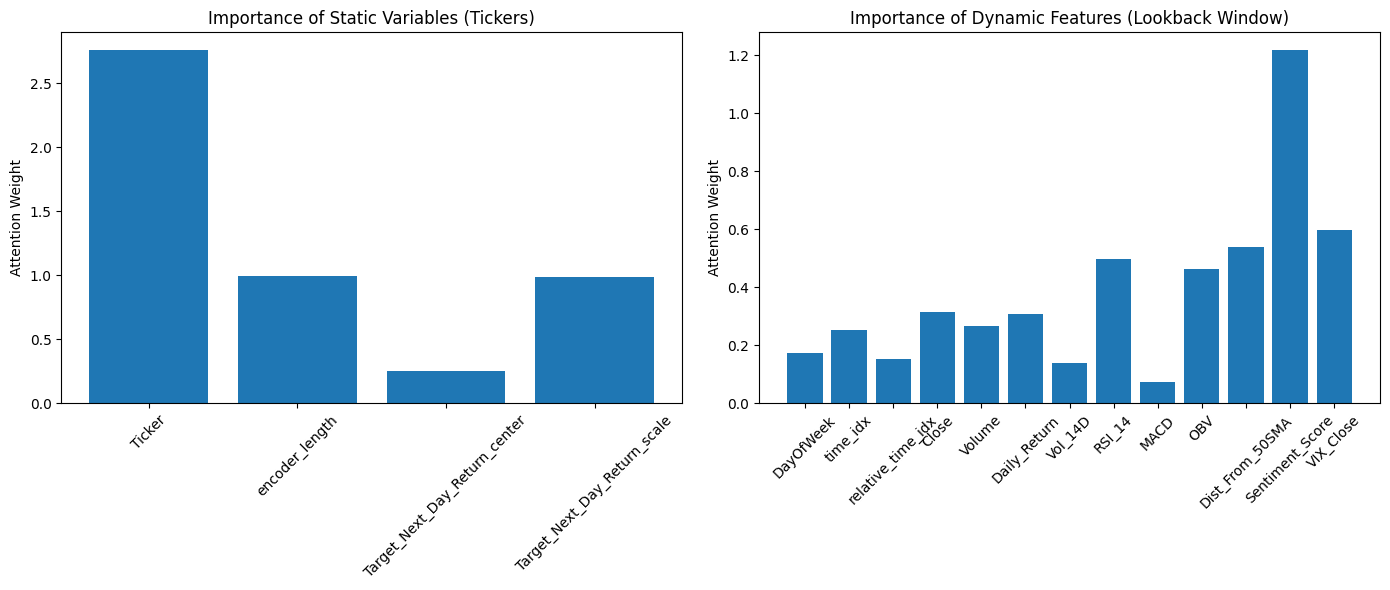

Plotting the Quantile Forecast...


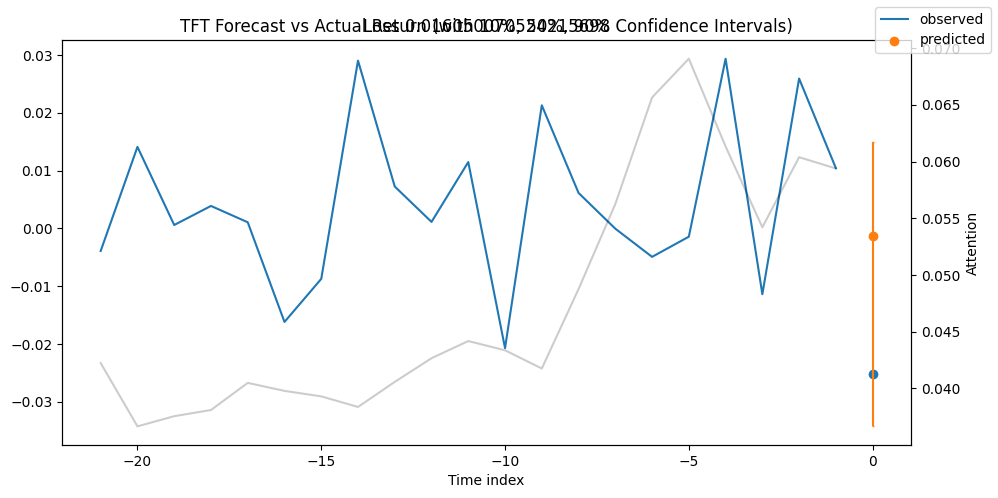

In [ ]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer


df = pd.read_parquet("C:\Jai's work\PycharmProjects\Stock_predictor_new\codebase\dataset_ready.parquet")
df = df.sort_values(by=['Ticker', 'Date'])
df['time_idx'] = df.groupby('Ticker').cumcount()
df['DayOfWeek'] = df['Date'].dt.dayofweek.astype(str)

max_encoder_length = 21
max_prediction_length = 1
training_cutoff = df["time_idx"].max() - 30

training_dataset = TimeSeriesDataSet(
    df[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="Target_Next_Day_Return",
    group_ids=["Ticker"],
    min_encoder_length=max_encoder_length,  
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["Ticker"],
    time_varying_known_categoricals=["DayOfWeek"],
    time_varying_known_reals=["time_idx"],
    time_varying_unknown_reals=[
        "Close", "Volume", "Daily_Return", "Vol_14D", 
        "RSI_14", "MACD", "OBV", "Dist_From_50SMA", "Sentiment_Score", "VIX_Close"
    ],
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation_dataset = TimeSeriesDataSet.from_dataset(
    training_dataset, df, predict=True, stop_randomization=True
)
val_dataloader = validation_dataset.to_dataloader(train=False, batch_size=64, num_workers=4)

print("Loading the optimized checkpoint...")
best_model_path = "tft_finance_model_2.ckpt"
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

raw_predictions = best_tft.predict(val_dataloader, mode="raw", return_x=True)

interpretation = best_tft.interpret_output(raw_predictions.output, reduction="sum")

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
static_importance = interpretation["static_variables"].detach().cpu().numpy()
plt.bar(best_tft.static_variables, static_importance)
plt.title("Importance of Static Variables (Tickers)")
plt.ylabel("Attention Weight")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
dynamic_importance = interpretation["encoder_variables"].detach().cpu().numpy()
plt.bar(best_tft.encoder_variables, dynamic_importance)
plt.title("Importance of Dynamic Features (Lookback Window)")
plt.ylabel("Attention Weight")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Plotting the Quantile Forecast...")
fig, ax = plt.subplots(figsize=(10, 5))
best_tft.plot_prediction(raw_predictions.x, raw_predictions.output, idx=0, ax=ax, add_loss_to_title=True)
plt.title("TFT Forecast vs Actual Return (with 10%, 50%, 90% Confidence Intervals)")
plt.show()

In [17]:
training_dataset.save("training_ds.pkl")